# Simple Linear Regression — CGPA vs Package

A step-by-step learning notebook: explore the data, train a scikit-learn Linear Regression model, evaluate it (MAE, MSE, RMSE, R², Adjusted R²), and finally implement Simple Linear Regression **from scratch** to see what's happening under the hood.

## 1. Import Libraries and Load the Dataset

In [119]:
import pandas as pd

# Load Dataset
df = pd.read_csv("placement.csv")

## 2. Explore the Data

In [120]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [121]:
df.shape

(200, 2)

In [122]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 2


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [124]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


## 3. Visualize the Relationship between CGPA and Package

In [125]:
import matplotlib.pyplot as plt

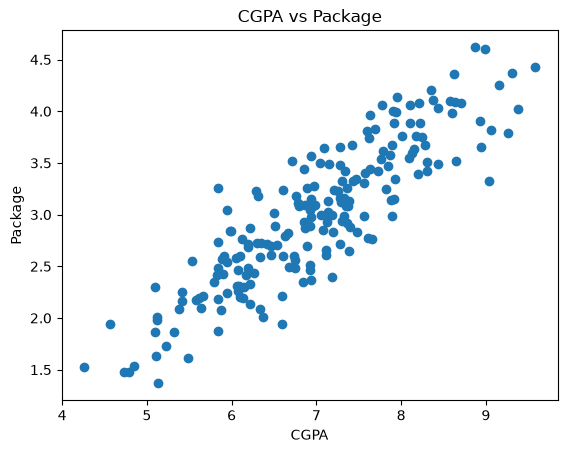

In [126]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.title('CGPA vs Package')
plt.show()

## 4. Prepare Features (X) and Target (y)

In [127]:
# Double brackets -> keeps X as a 2D DataFrame, which sklearn expects
X = df[['cgpa']]
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [128]:
y = df['package']
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [129]:
print(X.shape)
print(y.shape)

(200, 1)
(200,)


## 5. Train-Test Split

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


## 6. Train the Linear Regression Model (scikit-learn)

In [132]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [133]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.57]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.027
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 7. Make Predictions

In [134]:
y_pred = model.predict(X_test)
print(y_pred)

[2.78031348 3.13635249 3.1995207  2.38981908 3.52684689 3.76803461
 3.16506531 2.54486832 3.17655044 3.4923915  1.90744364 2.34962112
 3.6876387  2.75734322 3.47516381 3.04447145 2.32665086 3.20526327
 2.17734418 3.314372   2.45298729 2.90090734 3.32011456 2.87219451
 3.33734226 2.19457187 1.41932564 2.7114027  3.18229301 2.32665086
 3.74506435 2.95833298 3.68189614 2.97556068 2.59080884 3.34882738
 2.47595755 3.07318428 4.17575671 2.95833298]


In [135]:
print(y_pred.shape)

(40,)


Text(0, 0.5, 'Package(in lpa)')

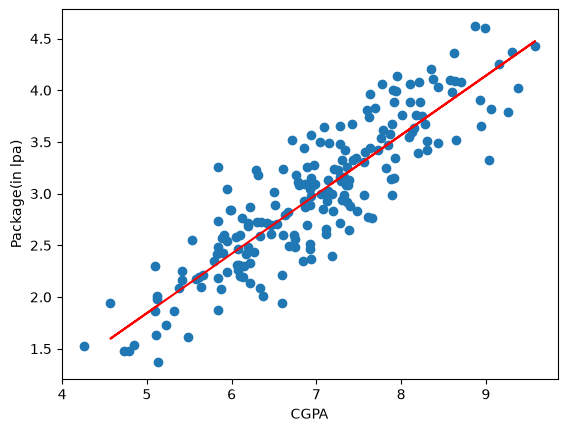

In [137]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,model.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [138]:
comparison = pd.DataFrame({
    'Actual Values': y_test.values,
    'Predicted Values': y_pred
})

print(comparison)

    Actual Values  Predicted Values
0            2.79          2.780313
1            3.23          3.136352
2            3.26          3.199521
3            3.04          2.389819
4            3.34          3.526847
5            4.21          3.768035
6            2.94          3.165065
7            2.87          2.544868
8            2.99          3.176550
9            3.58          3.492392
10           1.63          1.907444
11           2.08          2.349621
12           4.08          3.687639
13           2.21          2.757343
14           3.47          3.475164
15           3.64          3.044471
16           2.74          2.326651
17           3.08          3.205263
18           2.17          2.177344
19           2.99          3.314372
20           2.31          2.452987
21           2.35          2.900907
22           3.40          3.320115
23           3.08          2.872195
24           3.81          3.337342
25           2.19          2.194572
26           1.53          1

In [139]:
comparison['Error'] = comparison['Actual Values'] - comparison['Predicted Values']
print(comparison)

    Actual Values  Predicted Values     Error
0            2.79          2.780313  0.009687
1            3.23          3.136352  0.093648
2            3.26          3.199521  0.060479
3            3.04          2.389819  0.650181
4            3.34          3.526847 -0.186847
5            4.21          3.768035  0.441965
6            2.94          3.165065 -0.225065
7            2.87          2.544868  0.325132
8            2.99          3.176550 -0.186550
9            3.58          3.492392  0.087608
10           1.63          1.907444 -0.277444
11           2.08          2.349621 -0.269621
12           4.08          3.687639  0.392361
13           2.21          2.757343 -0.547343
14           3.47          3.475164 -0.005164
15           3.64          3.044471  0.595529
16           2.74          2.326651  0.413349
17           3.08          3.205263 -0.125263
18           2.17          2.177344 -0.007344
19           2.99          3.314372 -0.324372
20           2.31          2.45298

## 8. Evaluate the Model — Error Metrics

### Manual calculation

In [140]:
# Calculate Mean Absolute Error (MAE)
# First we need the Absolute Error.
comparison['Absolute Error'] = comparison['Error'].abs()
print(comparison)

    Actual Values  Predicted Values     Error  Absolute Error
0            2.79          2.780313  0.009687        0.009687
1            3.23          3.136352  0.093648        0.093648
2            3.26          3.199521  0.060479        0.060479
3            3.04          2.389819  0.650181        0.650181
4            3.34          3.526847 -0.186847        0.186847
5            4.21          3.768035  0.441965        0.441965
6            2.94          3.165065 -0.225065        0.225065
7            2.87          2.544868  0.325132        0.325132
8            2.99          3.176550 -0.186550        0.186550
9            3.58          3.492392  0.087608        0.087608
10           1.63          1.907444 -0.277444        0.277444
11           2.08          2.349621 -0.269621        0.269621
12           4.08          3.687639  0.392361        0.392361
13           2.21          2.757343 -0.547343        0.547343
14           3.47          3.475164 -0.005164        0.005164
15      

In [141]:
# Since we have Absolute Error now
mae = comparison['Absolute Error'].mean()
print(mae)

0.23150985393278373


In [142]:
# Calculate Mean Squared Error.
# NOTE: square the (signed) Error, not the Absolute Error - the name was misleading
# even though (|x|)**2 == x**2, so the numeric result was already correct.
comparison['Squared Error'] = comparison['Error'] ** 2
print(comparison)

    Actual Values  Predicted Values     Error  Absolute Error  Squared Error
0            2.79          2.780313  0.009687        0.009687       0.000094
1            3.23          3.136352  0.093648        0.093648       0.008770
2            3.26          3.199521  0.060479        0.060479       0.003658
3            3.04          2.389819  0.650181        0.650181       0.422735
4            3.34          3.526847 -0.186847        0.186847       0.034912
5            4.21          3.768035  0.441965        0.441965       0.195333
6            2.94          3.165065 -0.225065        0.225065       0.050654
7            2.87          2.544868  0.325132        0.325132       0.105711
8            2.99          3.176550 -0.186550        0.186550       0.034801
9            3.58          3.492392  0.087608        0.087608       0.007675
10           1.63          1.907444 -0.277444        0.277444       0.076975
11           2.08          2.349621 -0.269621        0.269621       0.072696

In [143]:
# Since we have Squared Error now
mse = comparison['Squared Error'].mean()
print(mse)

0.08417638361329657


In [144]:
# Calculate Root Mean Squared Error (RMSE)
rmse = mse ** 0.5
print(rmse)

0.2901316659954521


### Using scikit-learn (to double-check the manual results)

In [145]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_sklearn = mean_absolute_error(y_test, y_pred)
mse_sklearn = mean_squared_error(y_test, y_pred)
rmse_sklearn = mse_sklearn ** 0.5

print("MAE is : ", mae_sklearn)
print("MSE is : ", mse_sklearn)
print("RMSE is : ", rmse_sklearn)

MAE is :  0.23150985393278373
MSE is :  0.08417638361329657
RMSE is :  0.2901316659954521


In [146]:
diff_in_MAE = mae - mae_sklearn
print(diff_in_MAE)

0.0


## 9. R² Score (Coefficient of Determination)

### Understanding R² with a Tiny Example

Before calculating R² on our real CGPA vs Package dataset, we will calculate it manually on a tiny dataset.

The purpose is to understand:

- Mean / baseline prediction
- SST — Total Sum of Squares
- SSE — Sum of Squared Errors
- R² — Coefficient of Determination

In [147]:
actual = [10, 20, 30, 40]
predicted = [11, 18, 31, 39]

In [148]:
import numpy as np

mean = np.mean(actual)
print(mean)

25.0


In [149]:
sst = sum((y - mean) ** 2 for y in actual)
print(sst)

500.0


In [150]:
sse = sum((y - y_hat) ** 2 for y, y_hat in zip(actual, predicted))
print(sse)

7


In [151]:
r2 = 1 - (sse / sst)
print(r2)

0.986


### R² Score: CGPA vs Package Model

> **Purpose:** Apply everything we learned in the tiny example to our actual Linear Regression model.
>
> Here we will:
> - Calculate SST using `y_test`
> - Calculate SSE using `y_test` and `y_pred`
> - Calculate R² manually
> - Calculate R² using `sklearn`
> - Compare both results
> - Interpret the `R²` of our actual model
>
> **This is the actual evaluation of our CGPA → Package Linear Regression model.**

In [152]:
# Calculate Mean of Actual Values
y_mean = y_test.mean()
print("Mean of y_test:", y_mean)

Mean of y_test: 2.99675


In [153]:
sst = sum((y - y_mean) ** 2 for y in y_test)
print("SST:", sst)

SST: 14.839277500000003


In [154]:
sse = sum((y - y_hat) ** 2 for y, y_hat in zip(y_test, y_pred))
print("SSE:", sse)

SSE: 3.3670553445318623


In [155]:
# Manual calculation of the R² score
r2_manual = 1 - (sse / sst)
print("Manual R²:", r2_manual)

Manual R²: 0.7730984312051674


In [156]:
from sklearn.metrics import r2_score

r2_sklearn = r2_score(y_test, y_pred)
print("Sklearn R² score is:", r2_sklearn)

Sklearn R² score is: 0.7730984312051673


In [157]:
difference = r2_manual - r2_sklearn
print("Difference:", difference)

Difference: 1.1102230246251565e-16


### Adjusted R² Score

In [158]:
r2 = r2_sklearn
n = len(y_test)
k = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - 1 - k)

print("R²:", r2)
print("n:", n)
print("k:", k)
print("Adjusted R² score is:", adjusted_r2)

R²: 0.7730984312051673
n: 40
k: 1
Adjusted R² score is: 0.7671273372895138


## 10. Implementing Linear Regression From Scratch

Now, instead of relying on scikit-learn, we calculate the slope `m` and intercept `b` ourselves using the least-squares formulas, and use them to predict values.

First, let's check what `X_train` and `y_train` actually are — this matters because `train_test_split` keeps the *original* (shuffled) DataFrame index, so we can't safely loop over them using `X_train[i]` / `y_train[i]`.

In [159]:
print(type(X_train))
print(X_train.shape)
print(X_train.head())
print(X_train.index)

<class 'pandas.DataFrame'>
(160, 1)
     cgpa
79   7.18
197  7.21
38   8.62
24   6.53
122  5.12
Index([ 79, 197,  38,  24, 122, 195,  29,  19, 143,  86,
       ...
       121, 199,  20, 188,  71, 106,  14,  92, 179, 102],
      dtype='int64', length=160)


In [160]:
print(type(y_train))
print(y_train.shape)
print(y_train.head())
print(y_train.index)

<class 'pandas.Series'>
(160,)
79     3.00
197    3.24
38     4.36
24     2.71
122    2.01
Name: package, dtype: float64
Index([ 79, 197,  38,  24, 122, 195,  29,  19, 143,  86,
       ...
       121, 199,  20, 188,  71, 106,  14,  92, 179, 102],
      dtype='int64', length=160)


The two print cells above show why we can't just loop over `X_train`/`y_train` as-is: `train_test_split` keeps the *original* (shuffled) DataFrame index, so `X_train[i]` for `i = 0, 1, 2...` would not reliably give you row `i`.

The fix doesn't need to happen inside the class at all — we just pass `.values` when calling `fit`/`predict`, which converts the DataFrame/Series to a plain NumPy array with normal 0, 1, 2... positional indexing. The class itself stays exactly as simple as the original version. It's renamed to `SimpleLinearRegression` only so it doesn't shadow the `LinearRegression` class imported from scikit-learn earlier.

In [161]:
class SimpleLinearRegression:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + ((X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean()))

        self.m = num / den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)

    def predict(self, X_test):
        return self.m * X_test + self.b

In [162]:
scratch_model = SimpleLinearRegression()

In [163]:
# .values.ravel() -> plain 1D NumPy array (X_train is 2D since X = df[['cgpa']])
scratch_model.fit(X_train.values.ravel(), y_train.values)

0.5742564727019197
-1.0270069374542108


### Predict Using the Scratch Model and Compare with scikit-learn

In [164]:
y_pred_scratch = scratch_model.predict(X_test.values.ravel())
print(y_pred_scratch)

[2.78031348 3.13635249 3.1995207  2.38981908 3.52684689 3.76803461
 3.16506531 2.54486832 3.17655044 3.4923915  1.90744364 2.34962112
 3.6876387  2.75734322 3.47516381 3.04447145 2.32665086 3.20526327
 2.17734418 3.314372   2.45298729 2.90090734 3.32011456 2.87219451
 3.33734226 2.19457187 1.41932564 2.7114027  3.18229301 2.32665086
 3.74506435 2.95833298 3.68189614 2.97556068 2.59080884 3.34882738
 2.47595755 3.07318428 4.17575671 2.95833298]


In [165]:
comparison_scratch = pd.DataFrame({
    'Actual Values': y_test.values,
    'sklearn Prediction': y_pred,
    'Scratch Prediction': y_pred_scratch
})

print(comparison_scratch)

    Actual Values  sklearn Prediction  Scratch Prediction
0            2.79            2.780313            2.780313
1            3.23            3.136352            3.136352
2            3.26            3.199521            3.199521
3            3.04            2.389819            2.389819
4            3.34            3.526847            3.526847
5            4.21            3.768035            3.768035
6            2.94            3.165065            3.165065
7            2.87            2.544868            2.544868
8            2.99            3.176550            3.176550
9            3.58            3.492392            3.492392
10           1.63            1.907444            1.907444
11           2.08            2.349621            2.349621
12           4.08            3.687639            3.687639
13           2.21            2.757343            2.757343
14           3.47            3.475164            3.475164
15           3.64            3.044471            3.044471
16           2

In [166]:
r2_scratch = r2_score(y_test, y_pred_scratch)
print("R² (scratch model):", r2_scratch)
print("R² (sklearn model):", r2_sklearn)

R² (scratch model): 0.7730984312051673
R² (sklearn model): 0.7730984312051673
